In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
warnings.simplefilter('ignore')

In [72]:
df = pd.read_csv(r'/Users/tonmoydutta/Library/CloudStorage/OneDrive-Personal/Study Material/Self Elearning/Scaler/Product Analytics/5. Root Cause Analysis - 2/uber-data.csv', dayfirst = True, na_values = 'NA')
display(df.head(20))

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.0,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.0,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.0,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.0,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47
5,3879,Airport,1.0,Trip Completed,13-07-2016 21:57:28,13-07-2016 22:28:59
6,4270,Airport,1.0,Trip Completed,14-07-2016 06:15:32,14-07-2016 07:13:15
7,5510,Airport,1.0,Trip Completed,15-07-2016 05:11:52,15-07-2016 06:07:52
8,6248,City,1.0,Trip Completed,15-07-2016 17:57:27,15-07-2016 18:50:51
9,267,City,2.0,Trip Completed,11/7/2016 6:46,11/7/2016 7:25


In [73]:
print("Number of rows: {}".format(df.shape[0]))
print("Number of columns: {}". format(df.shape[1]))

Number of rows: 6745
Number of columns: 6


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   object 
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   object 
 4   Request timestamp  6745 non-null   object 
 5   Drop timestamp     2831 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 316.3+ KB


In [75]:
df['Request timestamp_1'] = pd.to_datetime(df['Request timestamp'], format = '%d-%m-%Y %H:%M:%S', errors = 'coerce')
df['Request timestamp_2'] = pd.to_datetime(df['Request timestamp'], format = '%d/%m/%Y %H:%M:%S', errors = 'coerce')
df['Request timestamp'] = df['Request timestamp_2'].combine_first(df['Request timestamp_1'])

df['Drop timestamp_1'] = pd.to_datetime(df['Drop timestamp'], format = '%d-%m-%Y %H:%M:%S', errors = 'coerce')
df['Drop timestamp_2'] = pd.to_datetime(df['Drop timestamp'], format = '%d/%m/%Y %H:%M:%S', errors = 'coerce')
df['Drop timestamp'] = df['Drop timestamp_2'].combine_first(df['Drop timestamp_1'])

In [76]:
df.drop(columns = ['Request timestamp_1', 'Request timestamp_2', 'Drop timestamp_1', 'Drop timestamp_2'], inplace = True)

In [77]:
df.isnull().sum() / len(df) * 100

Request id            0.000000
Pickup point          0.000000
Driver id            39.288362
Status                0.000000
Request timestamp    39.644181
Drop timestamp       75.077835
dtype: float64

In [78]:
print("Number of duplicated rows: {}".format(df.duplicated().sum()))

Number of duplicated rows: 0


In [79]:
df['RequestHour'] = df['Request timestamp'].dt.hour
display(df.head(10))

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,RequestHour
0,619,Airport,1.0,Trip Completed,NaT,NaT,NaN
1,867,Airport,1.0,Trip Completed,NaT,NaT,NaN
2,1807,City,1.0,Trip Completed,NaT,NaT,NaN
3,2532,Airport,1.0,Trip Completed,NaT,NaT,NaN
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,8.0
5,3879,Airport,1.0,Trip Completed,2016-07-13 21:57:28,2016-07-13 22:28:59,21.0
6,4270,Airport,1.0,Trip Completed,2016-07-14 06:15:32,2016-07-14 07:13:15,6.0
7,5510,Airport,1.0,Trip Completed,2016-07-15 05:11:52,2016-07-15 06:07:52,5.0
8,6248,City,1.0,Trip Completed,2016-07-15 17:57:27,2016-07-15 18:50:51,17.0
9,267,City,2.0,Trip Completed,NaT,NaT,NaN


In [80]:
df['TimeSlot'] = df['RequestHour'].apply(lambda x: "Dawn" if x <= 4 else ("Early Morning"
                                                                          if x <= 9 else ("Noon"
                                                                                          if x <= 16 else ("Late Evening"
                                                                                                           if x <= 21 else "Night"))))

In [81]:
df['Cab Availability'] = df['Status'].apply(lambda x: "Available" if x == "Trip Completed" else "Not Available")

In [82]:
df.sample(5)

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,RequestHour,TimeSlot,Cab Availability
5203,3011,City,NaN,No Cars Available,2016-07-13 07:22:33,NaT,7.0,Early Morning,Not Available
597,2815,City,63.0,Trip Completed,2016-07-13 05:13:32,2016-07-13 05:42:58,5.0,Early Morning,Available
5686,4262,City,NaN,No Cars Available,2016-07-14 06:15:24,NaT,6.0,Early Morning,Not Available
1049,1953,Airport,109.0,Trip Completed,NaT,NaT,NaN,Night,Available
1536,4385,City,162.0,Trip Completed,2016-07-14 07:51:59,2016-07-14 08:24:08,7.0,Early Morning,Available


In [83]:
df['Cab Availability'].value_counts(normalize = True) * 100

Cab Availability
Not Available    58.028169
Available        41.971831
Name: proportion, dtype: float64

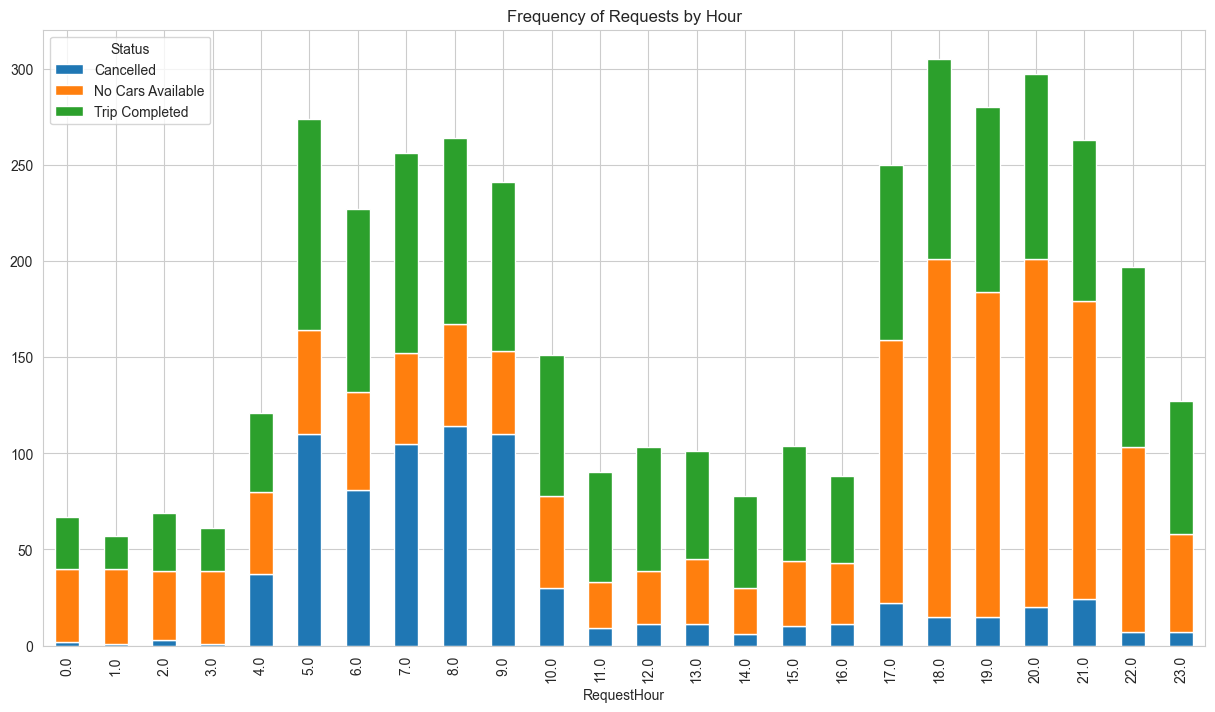

In [84]:
df.groupby(['RequestHour','Status']).size().unstack().plot(kind = 'bar', stacked = True, figsize = (15,8))
plt.title("Frequency of Requests by Hour")
plt.show()

In [85]:
df['Pickup point'].value_counts(normalize = True) * 100

Pickup point
City       51.99407
Airport    48.00593
Name: proportion, dtype: float64

In [86]:
df.groupby(['Pickup point','Cab Availability']).size().reset_index(name = 'count').assign(Percentage = lambda x: (x['count'] / x['count'].sum()) * 100)

,Pickup point,Cab Availability,count,Percentage
0,Airport,Available,1327,19.673832
1,Airport,Not Available,1911,28.332098
2,City,Available,1504,22.297999
3,City,Not Available,2003,29.696071


<Axes: xlabel='TimeSlot'>

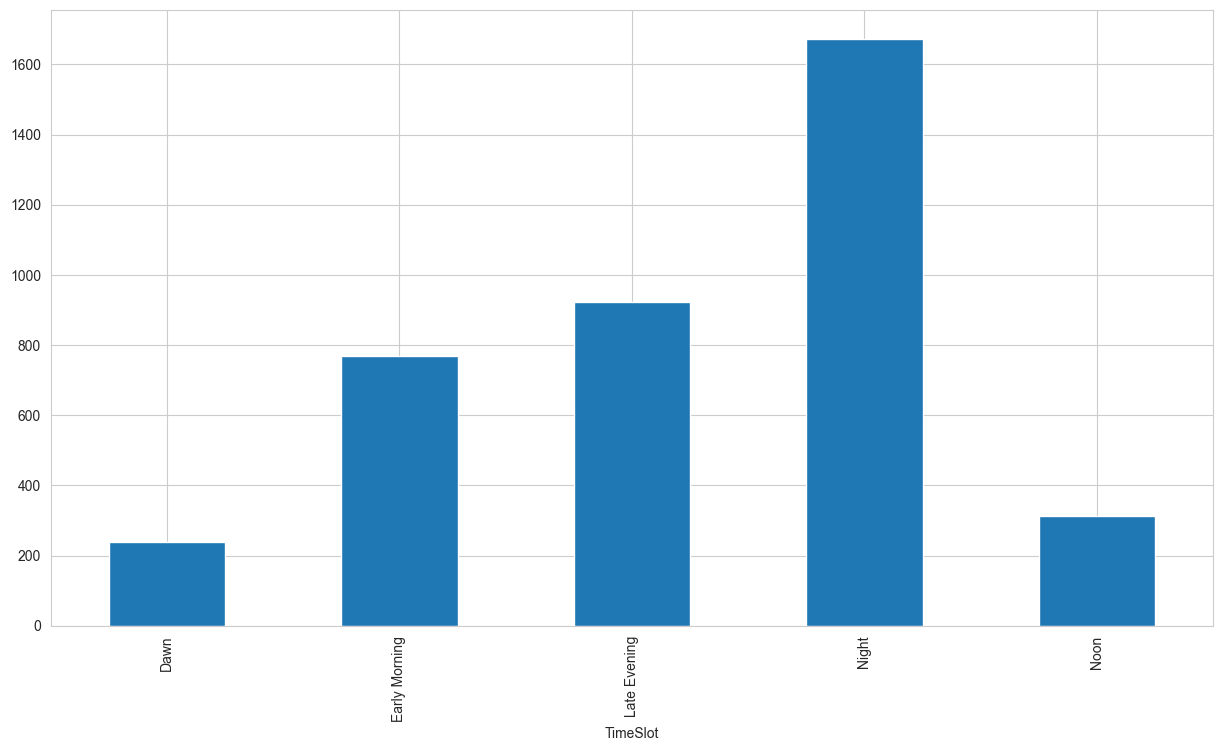

In [87]:
df[(df['Cab Availability'] == 'Not Available')].groupby(['TimeSlot']).size().plot(kind = 'bar', stacked = True, figsize = (15,8))

Text(0.5, 1.0, 'Demand-Supply Gap from Airport to City')

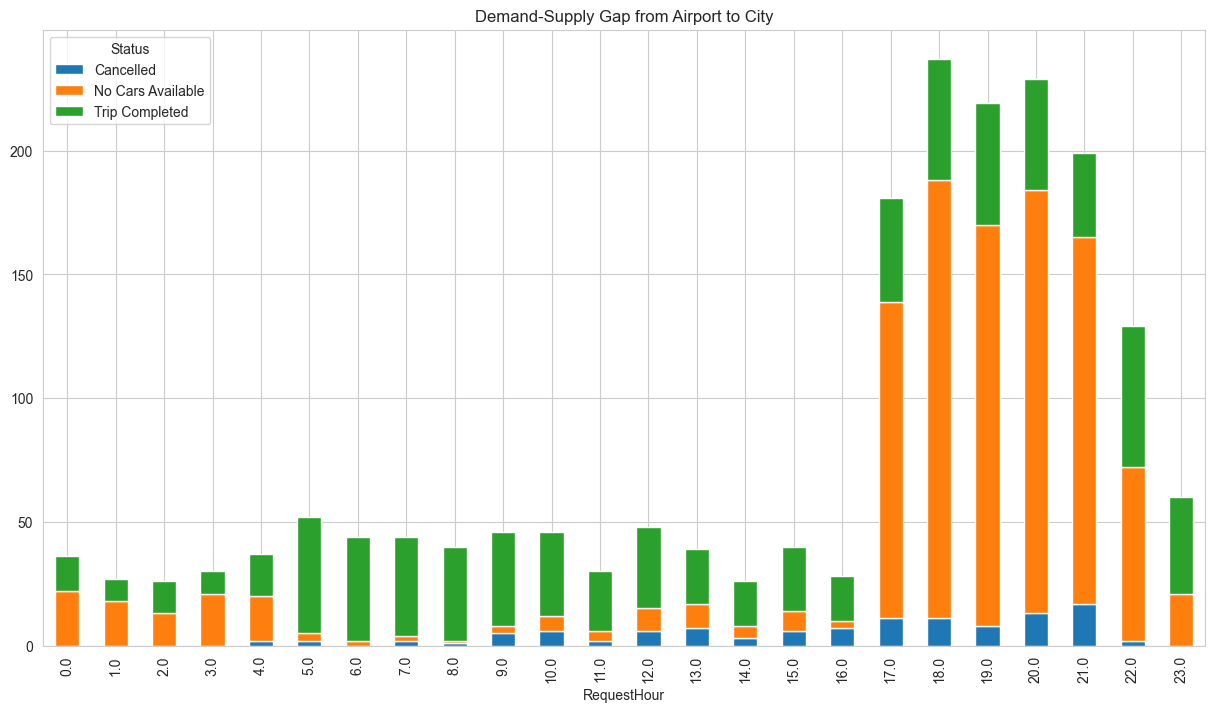

In [89]:
df[(df['Pickup point'] == 'Airport')].groupby(['RequestHour','Status']).size().unstack().plot(kind = 'bar', stacked = True, figsize = (15,8))
plt.title('Demand-Supply Gap from Airport to City')

Text(0.5, 1.0, 'Demand-Supply Gap from City to Airport')

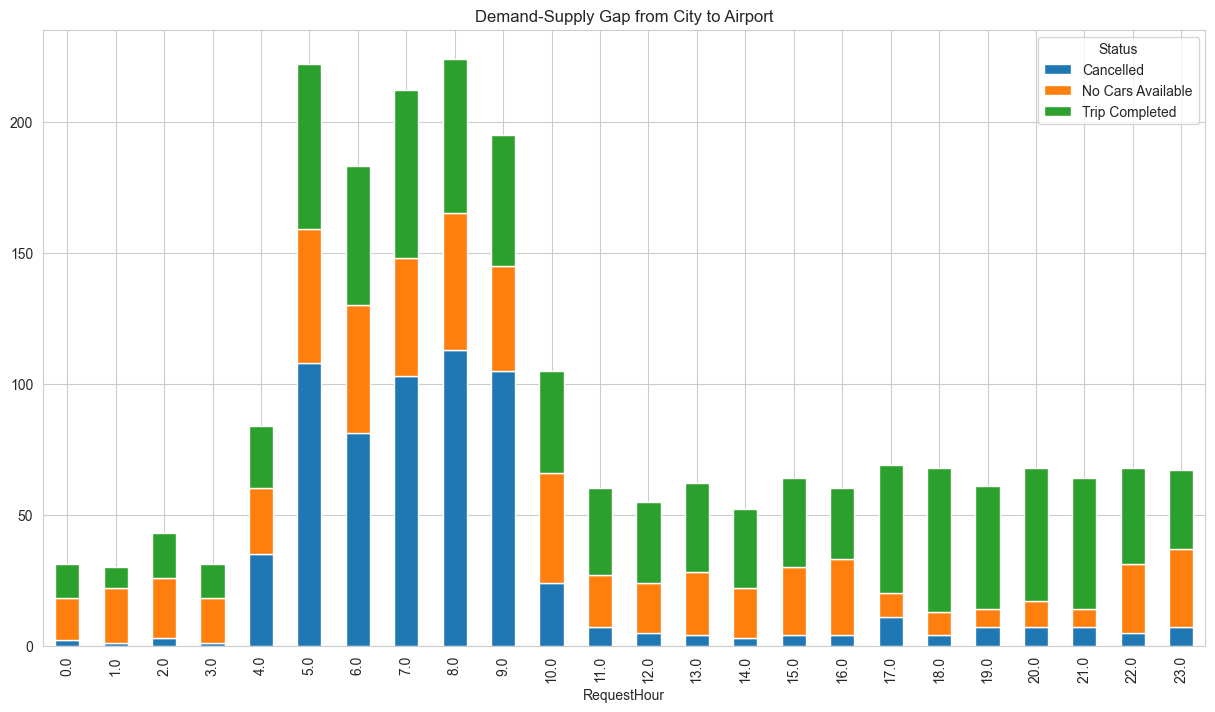

In [90]:
df[(df['Pickup point'] == 'City')].groupby(['RequestHour','Status']).size().unstack().plot(kind = 'bar', stacked = True, figsize = (15,8))
plt.title('Demand-Supply Gap from City to Airport')

Text(0.5, 1.0, 'Timeslot where highest gap exists')

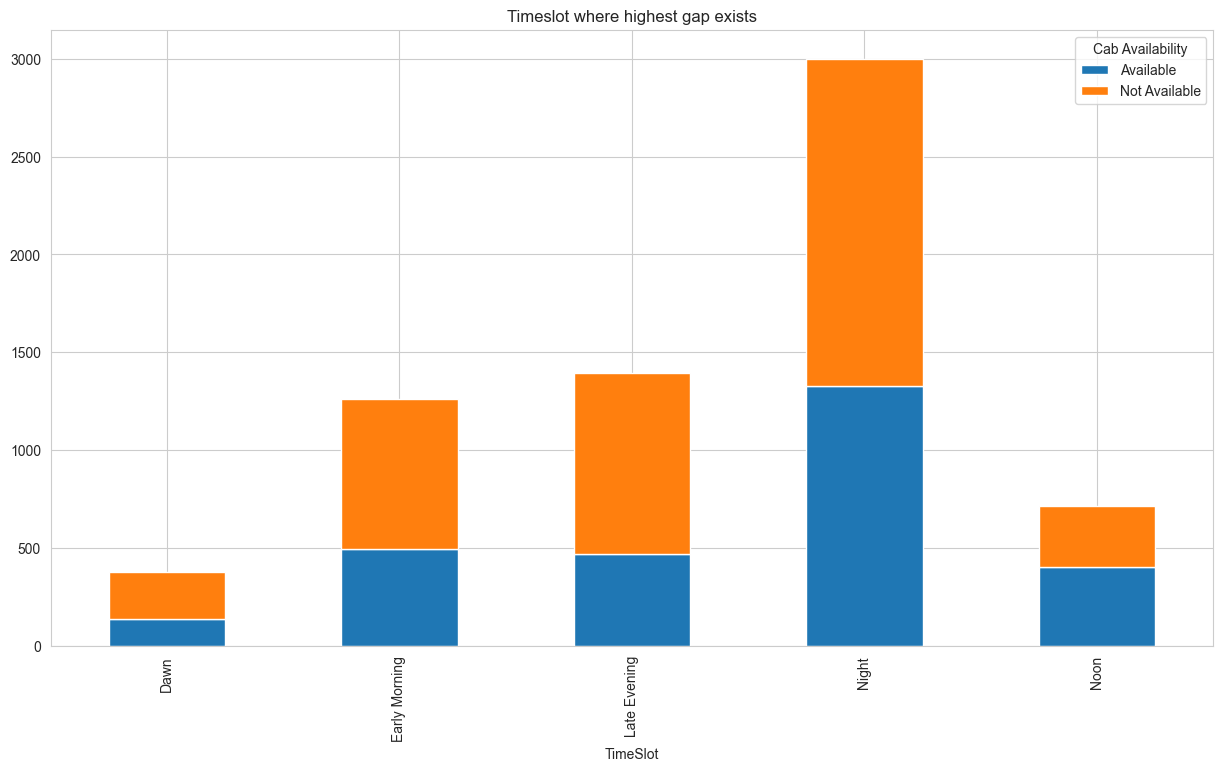

In [91]:
df.groupby(['TimeSlot','Cab Availability']).size().unstack().plot(kind = 'bar', stacked = True, figsize = (15,8))
plt.title('Timeslot where highest gap exists')

Text(0, 0.5, '')

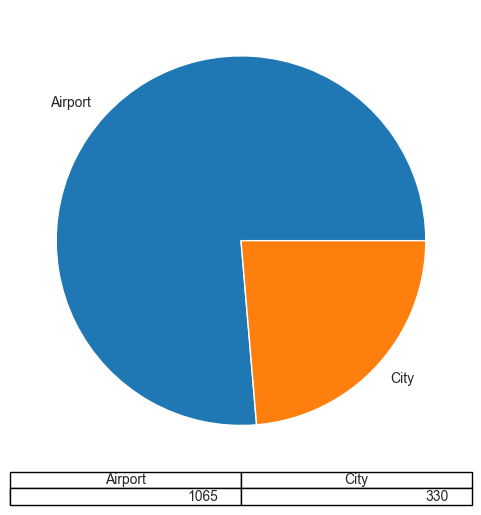

In [92]:
df[(df['TimeSlot'] == 'Late Evening')].groupby(['Pickup point']).size().plot(kind = 'pie', stacked = True, figsize = (6,6), table = True)
plt.ylabel("")